<Axes: xlabel='skill_count', ylabel='skill_pay'>

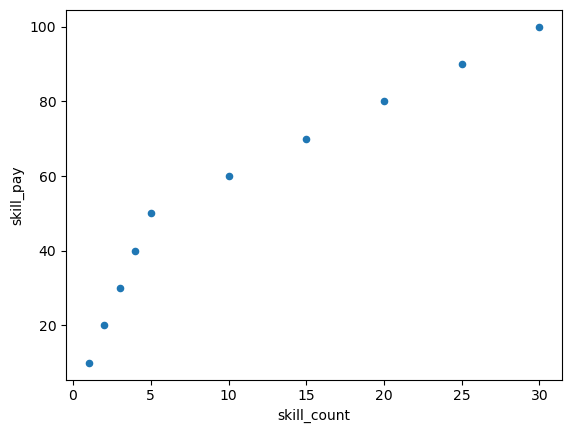

In [15]:
data={
    'job_skills':['python','sql','c++','c#','java','javascript','html','css','php','ruby'],
    'skill_count':[30,25,20,15,10,5,4,3,2,1],
    'skill_pay':[100,90,80,70,60,50,40,30,20,10]
}
df=pd.DataFrame(data)
df.plot(kind='scatter', x='skill_count',y='skill_pay')

In [3]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df=df[df['job_title_short']=='Data Analyst']


In [13]:
df_exploded=df.explode('job_skills')
skill_stats=df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)
skills_stats=skill_stats.sort_values(by='skill_count',ascending=False).head(10)
skills_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


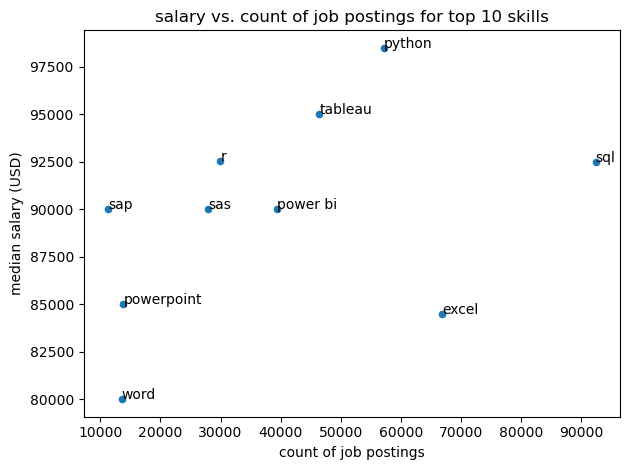

In [14]:
df_exploded=df.explode('job_skills')
skill_stats=df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)
skills_stats=skill_stats.sort_values(by='skill_count',ascending=False).head(10)
skills_stats.plot(kind='scatter', x='skill_count',y='median_salary')

plt.xlabel('count of job postings')
plt.ylabel('median salary (USD)')
plt.title('salary vs. count of job postings for top 10 skills')
plt.tight_layout()
for i , txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)
plt.show()